# Trackmania Monte Carlo Simulator — Exploration


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tmonacodel import TournamentConfig, run_monte_carlo, REAL_PLAYERS
from tmonacodel.player import make_player_pool

sns.set_theme(style='whitegrid')

## Run simulation


In [2]:
config = TournamentConfig(n_simulations=10_000, random_seed=None)
results = run_monte_carlo(config, player_data=REAL_PLAYERS)
print(f'Simulated {config.n_simulations} seasons with {config.n_players} players')
print(f'Real players: {len(REAL_PLAYERS)}, Generic fill: {config.n_players - len(REAL_PLAYERS)}')

Simulated 10000 seasons with 128 players
Real players: 98, Generic fill: 30


## Summary table


In [3]:
df = results.summary_dataframe()
df[['name', 'country', 'mean_rank', 'median_rank', 'prob_top_N']].head(20)

,name,country,mean_rank,median_rank,prob_top_N
0,Massa,Germany,63.0908,63.0,0.1314
1,Molle,Sweden,63.5137,63.0,0.1296
2,MimoJr,France,63.5972,63.0,0.1331
3,Binkss,France,63.6559,63.0,0.1247
4,josh1248,United Kingdom,63.7608,64.0,0.1314
5,neon,Poland,63.8741,64.0,0.1242
6,Tona,France,63.9327,64.0,0.1290
7,Generic_03,France,63.9329,63.0,0.1281
8,Epos,United Kingdom,63.9539,64.0,0.1249
9,Generic_28,Germany,63.9944,64.0,0.1277


## EWC Qualifying Score (PQ)

In [4]:
pq = results.ewc_qualifying_score(top_n=8)
print(f"PQ (guaranteed top-8 qualifying score): {pq} points")

PQ (guaranteed top-8 qualifying score): 1652 points


## Qualification likelihood by score

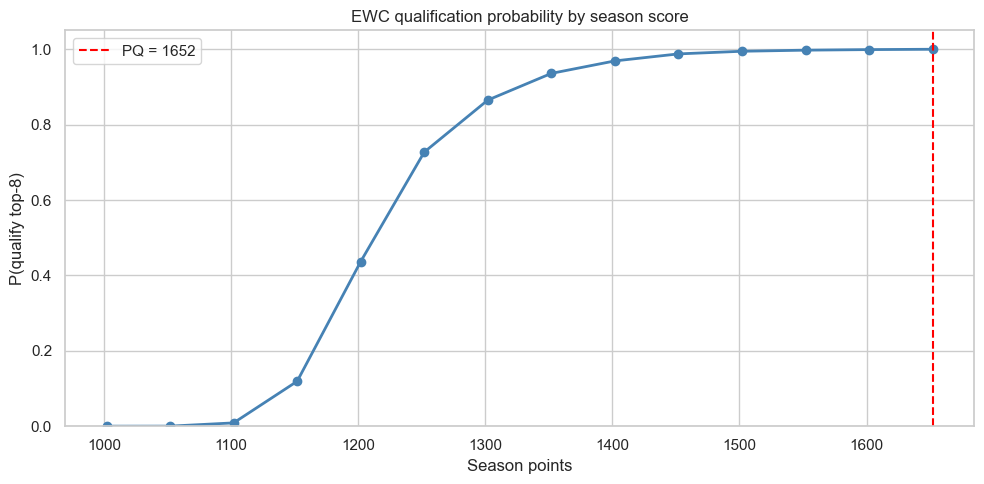

In [5]:
curve = results.ewc_qualification_curve(top_n=8, step=50)
curve_plot = curve.sort_values("score")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(curve_plot["score"], curve_plot["prob_qualify"], marker="o", linewidth=2, color="steelblue")
ax.axvline(pq, color="red", linestyle="--", label=f"PQ = {pq}")
ax.set_xlabel("Season points")
ax.set_ylabel("P(qualify top-8)")
ax.set_title("EWC qualification probability by season score")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Minimum score to top national table

In [6]:
nation_tops = results.nation_topping_scores()
nation_tops

,country,player_count,p90_score_to_top_nation
0,France,36,2176
1,Germany,15,1940
2,Poland,14,1896
3,United Kingdom,7,1716
4,United States,5,1608
5,Hungary,5,1592
6,Croatia,4,1512
7,Czechia,4,1504
8,Canada,3,1408
9,Turkey,3,1400


## Average points by finishing rank

In [7]:
rank_df = results.rank_points_profile()
print(rank_df[0:8].to_string(index=False))

 rank  mean_points  p10_points  p90_points
    1       2077.3        1694        2536
    2       1773.7        1502        2088
    3       1607.0        1380        1828
    4       1488.1        1288        1704
    5       1395.8        1234        1584
    6       1324.1        1200        1482
    7       1268.4        1172        1396
    8       1225.9        1148        1324


## Plot: Points distribution for one player


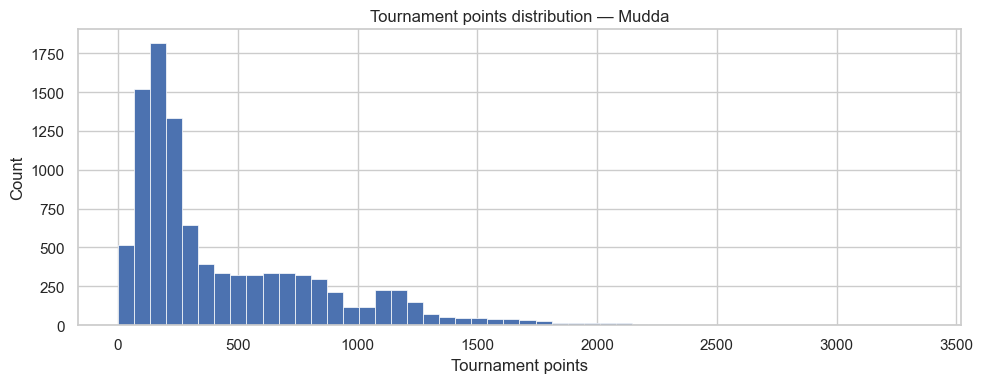

In [8]:
player_id = 0
dist = results.points_distribution(player_id)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dist, bins=50, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Tournament points')
ax.set_ylabel('Count')
ax.set_title(f'Tournament points distribution — {results.players[player_id].name}')
plt.tight_layout()
plt.show()

## Partial tournament with real results + derived skills

Four cups have been played (China, France, USA, Brazil). The remaining six are simulated.
Player skills are derived automatically from those four results: `mean(points) / 1000`, clipped
to `[0.01, 1.0]`. Generics get the 25th-percentile skill of named players, making them
realistically weak.

In [9]:
from tmonacodel import REAL_CUP_RESULTS, derive_skill

# Inspect derived skills for the named players
completed = [e for e in REAL_CUP_RESULTS if e is not None]
skill_map, generic_skill = derive_skill(completed, [])

print(f"Cups with real data: {len(completed)} / {len(REAL_CUP_RESULTS)}")
print(f"Named players with derived skill: {len(skill_map)}")
print(f"Generic player skill (25th percentile): {generic_skill:.3f}")
print()
print("Top 10 skills:")
for name, skill in sorted(skill_map.items(), key=lambda x: -x[1])[:10]:
    print(f"  {name:<16} {skill:.3f}")

Cups with real data: 4 / 10
Named players with derived skill: 98
Generic player skill (25th percentile): 0.020

Top 10 skills:
  Mudda            0.516
  Carl Jr.         0.408
  Massa            0.377
  Binkss           0.352
  Wosile           0.346
  Nayko            0.270
  Tona             0.263
  GranaDy          0.230
  Xerar            0.224
  Bren             0.222


In [10]:
skilled_config = TournamentConfig(n_simulations=10_000, random_seed=42)
skilled_results = run_monte_carlo(skilled_config, player_data=REAL_PLAYERS, real_cup_results=REAL_CUP_RESULTS)

print(f"Simulated {skilled_config.n_simulations} seasons")
print(f"Fixed cups: {sum(e is not None for e in REAL_CUP_RESULTS)} — Simulated cups: {sum(e is None for e in REAL_CUP_RESULTS)}")

Simulated 10000 seasons
Fixed cups: 4 — Simulated cups: 6


### Leaderboard: real results + skill-biased projection

In [11]:
skilled_df = skilled_results.summary_dataframe()
skilled_df[['name', 'country', 'mean_rank', 'median_rank', 'p10_points', 'p50_points', 'prob_top_N']].head(20)

,name,country,mean_rank,median_rank,p10_points,p50_points,prob_top_N
0,Mudda,Australia,1.6952,1.0,2800,3600,1.0000
1,Carl Jr.,Canada,3.5272,3.0,2092,2896,1.0000
2,Massa,Germany,4.3363,4.0,1988,2600,1.0000
3,Binkss,France,4.7257,4.0,1800,2500,1.0000
4,Wosile,France,4.9164,5.0,1779,2500,1.0000
5,Nayko,France,8.9036,8.0,1072,1792,0.9512
6,GranaDy,Germany,9.5686,9.0,1056,1680,0.9388
7,Bren,France,9.9803,10.0,1040,1644,0.9243
8,Tona,France,10.9660,10.0,852,1568,0.8326
9,Xerar,France,10.9982,10.0,908,1524,0.8334


### Skill vs uniform: prob_top_N comparison

The uniform run (no real results) spreads `prob_top_N` almost flatly across all players.
The skilled run should show a sharp peak for the elite and a long tail for generics.

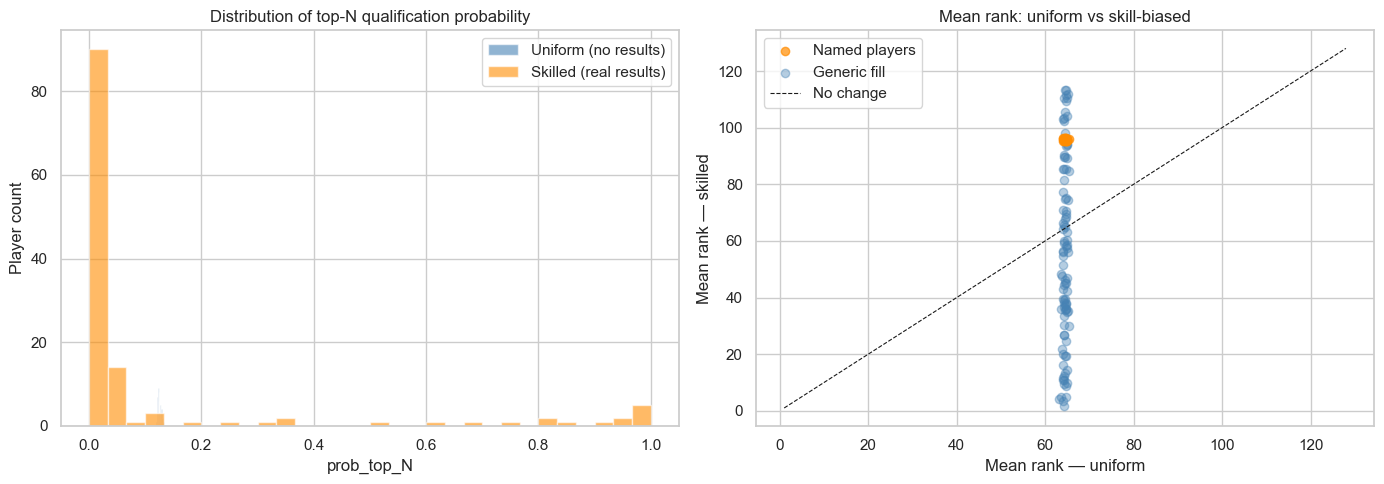


Largest skill gains (most improved vs uniform):
    name  uniform_prob  skilled_prob  prob_delta
  Wosile        0.1221        1.0000      0.8779
  Binkss        0.1247        1.0000      0.8753
Carl Jr.        0.1262        1.0000      0.8738
   Mudda        0.1271        1.0000      0.8729
   Massa        0.1314        1.0000      0.8686
   Nayko        0.1264        0.9512      0.8248
 GranaDy        0.1239        0.9388      0.8149
    Bren        0.1244        0.9243      0.7999


In [12]:
import pandas as pd

# Align the two runs on player name for comparison
uniform_df = results.summary_dataframe()  # the run from the top of the notebook

compare = (
    skilled_df[['name', 'prob_top_N', 'mean_rank']]
    .rename(columns={'prob_top_N': 'skilled_prob', 'mean_rank': 'skilled_rank'})
    .merge(
        uniform_df[['name', 'prob_top_N', 'mean_rank']]
        .rename(columns={'prob_top_N': 'uniform_prob', 'mean_rank': 'uniform_rank'}),
        on='name',
    )
)
compare['prob_delta'] = compare['skilled_prob'] - compare['uniform_prob']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: prob_top_N distributions
axes[0].hist(uniform_df['prob_top_N'], bins=30, alpha=0.6, label='Uniform (no results)', color='steelblue')
axes[0].hist(skilled_df['prob_top_N'], bins=30, alpha=0.6, label='Skilled (real results)', color='darkorange')
axes[0].set_xlabel('prob_top_N')
axes[0].set_ylabel('Player count')
axes[0].set_title('Distribution of top-N qualification probability')
axes[0].legend()

# Right: scatter uniform rank vs skilled rank
is_named = ~compare['name'].str.startswith('Generic_')
axes[1].scatter(compare.loc[~is_named, 'uniform_rank'], compare.loc[~is_named, 'skilled_rank'],
                alpha=0.7, label='Named players', color='darkorange', zorder=3)
axes[1].scatter(compare.loc[is_named, 'uniform_rank'], compare.loc[is_named, 'skilled_rank'],
                alpha=0.4, label='Generic fill', color='steelblue')
lims = [1, config.n_players]
axes[1].plot(lims, lims, 'k--', linewidth=0.8, label='No change')
axes[1].set_xlabel('Mean rank — uniform')
axes[1].set_ylabel('Mean rank — skilled')
axes[1].set_title('Mean rank: uniform vs skill-biased')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nLargest skill gains (most improved vs uniform):")
print(compare.sort_values('prob_delta', ascending=False)[['name', 'uniform_prob', 'skilled_prob', 'prob_delta']].head(8).to_string(index=False))

## EWC qualifying score (skill-biased run)

PQ (guaranteed top-8 qualifying score, skill-biased): 2692 points


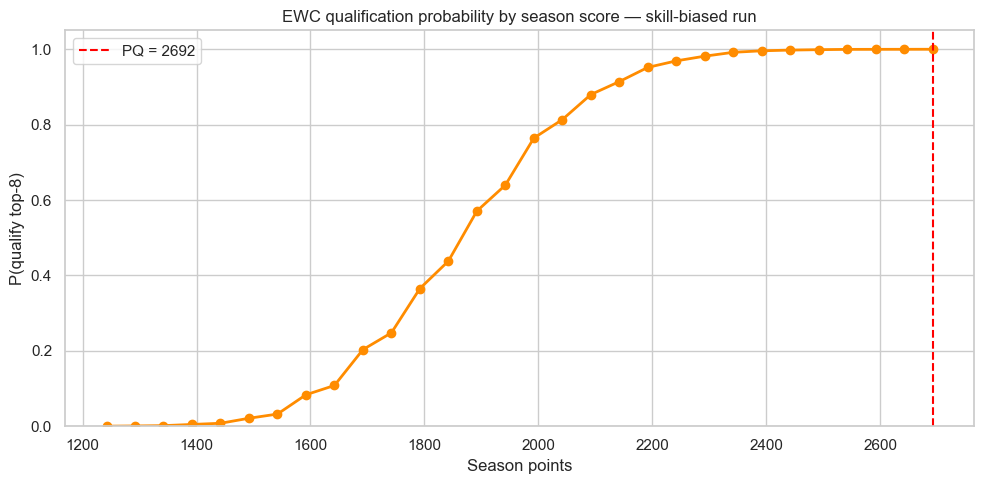

In [13]:
skilled_pq = skilled_results.ewc_qualifying_score(top_n=8)
print(f"PQ (guaranteed top-8 qualifying score, skill-biased): {skilled_pq} points")

skilled_curve = skilled_results.ewc_qualification_curve(top_n=8, step=50)
curve_plot = skilled_curve.sort_values("score")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(curve_plot["score"], curve_plot["prob_qualify"], marker="o", linewidth=2, color="darkorange")
ax.axvline(skilled_pq, color="red", linestyle="--", label=f"PQ = {skilled_pq}")
ax.set_xlabel("Season points")
ax.set_ylabel("P(qualify top-8)")
ax.set_title("EWC qualification probability by season score — skill-biased run")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Minimum score to top national table (skill-biased run)

In [14]:
skilled_results.nation_topping_scores()

,country,player_count,p90_score_to_top_nation
0,Canada,2,3700
1,France,34,3700
2,Germany,15,3300
3,United Kingdom,9,2300
4,Belgium,3,1972
5,Czechia,3,1788
6,Netherlands,3,1316
7,Russia,2,1212
8,Poland,13,1066
9,Hungary,3,1044


## Qualification likelihood by score (skill-biased run)

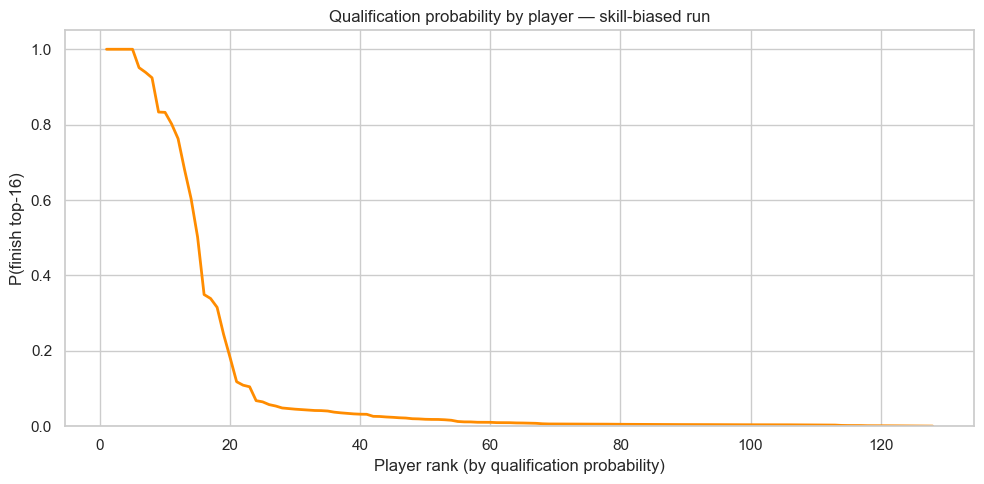

Top 20 qualification probabilities:
Mudda       1.0000
Massa       1.0000
Binkss      1.0000
Wosile      1.0000
Carl Jr.    1.0000
Nayko       0.9512
GranaDy     0.9388
Bren        0.9243
Xerar       0.8334
Tona        0.8326
Epos        0.8020
Otaaaq      0.7629
Gwen        0.6804
Scrapie     0.6037
eLconn21    0.5019
Heav        0.3492
Whizzy      0.3387
Legu        0.3153
josh1248    0.2435
Stufts      0.1818


In [17]:
skilled_qual_probs = skilled_results.qualification_probabilities()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(skilled_qual_probs) + 1), skilled_qual_probs.values,
        linewidth=2, color="darkorange")
ax.set_xlabel("Player rank (by qualification probability)")
ax.set_ylabel("P(finish top-16)")
ax.set_title("Qualification probability by player — skill-biased run")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("Top 20 qualification probabilities:")
print(skilled_qual_probs.head(20).to_string())

## Top-16 positional breakdown (skill-biased run)

For the 16 players with the highest average tournament points, this table shows:
- **Pos 1 … Pos 16**: percentage of simulations in which they finished at exactly that rank
- **avg_rank**: mean finishing rank across all simulations
- **avg_points**: mean tournament points across all simulations

In [20]:
n_sims = skilled_config.n_simulations
ranks_arr = skilled_results.all_tournament_ranks   # (n_sims, n_players)
points_arr = skilled_results.all_tournament_points  # (n_sims, n_players)

# Identify top-16 players by mean points, then sort by mean rank within that group
mean_pts = points_arr.mean(axis=0)
mean_rnk = ranks_arr.mean(axis=0)
top16_ids = np.argsort(-mean_pts)[:16]
top16_ids = top16_ids[np.argsort(mean_rnk[top16_ids])]  # sort by mean rank

rows = []
for pid in top16_ids:
    player_ranks = ranks_arr[:, pid]
    player_pts   = points_arr[:, pid]
    row = {"Player": skilled_results.players[pid].name}
    for pos in range(1, 17):
        row[f"Pos {pos}"] = round((player_ranks == pos).mean() * 100, 1)
    row["avg_rank"]   = round(float(mean_rnk[pid]), 2)
    row["avg_points"] = round(float(mean_pts[pid]), 0)
    rows.append(row)

breakdown = pd.DataFrame(rows).set_index("Player")

# Style: highlight each row's column maximum (most likely finish position)
pos_cols = [f"Pos {k}" for k in range(1, 17)]

def highlight_max(row):
    max_val = row[pos_cols].max()
    return ["background-color: #ffe0a0" if (col in pos_cols and val == max_val) else ""
            for col, val in zip(row.index, row)]

breakdown.style\
    .format({col: "{:.1f}%" for col in pos_cols})\
    .format({"avg_rank": "{:.2f}", "avg_points": "{:.0f}"})\
    .apply(highlight_max, axis=1)\
    .set_caption("Top-16 players: % finishing at each rank position (skill-biased run)")

,Pos 1,Pos 2,Pos 3,Pos 4,Pos 5,Pos 6,Pos 7,Pos 8,Pos 9,Pos 10,Pos 11,Pos 12,Pos 13,Pos 14,Pos 15,Pos 16,avg_rank,avg_points
Player,,,,,,,,,,,,,,,,,,
Mudda,62.300000,20.400000,9.000000,4.500000,2.500000,1.000000,0.400000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.70,3586
Carl Jr.,15.200000,24.900000,18.500000,13.300000,10.000000,7.400000,4.700000,3.100000,1.700000,0.800000,0.200000,0.100000,0.000000,0.000000,0.000000,0.000000,3.53,2892
Massa,5.700000,15.200000,19.400000,18.800000,15.000000,10.000000,6.600000,4.100000,2.800000,1.500000,0.700000,0.200000,0.000000,0.000000,0.000000,0.000000,4.34,2625
Binkss,6.400000,14.300000,16.700000,15.300000,13.300000,11.200000,7.800000,6.100000,3.700000,2.700000,1.600000,0.600000,0.200000,0.000000,0.000000,0.000000,4.73,2579
Wosile,6.200000,12.700000,15.000000,15.500000,14.200000,11.200000,8.100000,6.400000,4.400000,3.000000,2.200000,0.800000,0.200000,0.000000,0.000000,0.000000,4.92,2554
Nayko,1.100000,2.900000,4.500000,5.900000,8.200000,9.300000,9.600000,9.200000,8.800000,8.100000,6.500000,5.300000,4.500000,4.100000,3.800000,3.400000,8.90,1878
GranaDy,0.700000,2.100000,3.400000,4.900000,6.600000,7.900000,9.300000,9.200000,8.400000,8.600000,7.400000,6.400000,5.500000,5.000000,4.600000,4.200000,9.57,1771
Bren,0.600000,1.700000,2.900000,4.300000,5.600000,6.900000,9.000000,8.700000,8.800000,8.300000,7.900000,6.700000,5.400000,5.400000,5.100000,5.000000,9.98,1722
Tona,0.500000,1.700000,2.800000,3.900000,5.100000,6.600000,7.100000,8.500000,8.100000,7.500000,6.900000,6.600000,5.400000,5.000000,3.900000,3.600000,10.97,1640
